In [1]:
import sys

print(sys.executable)

C:\Users\FRIENDSL\anaconda3\envs\customer_churn\python.exe


In [2]:
import pandas as pd

In [3]:
services = pd.read_csv("../data/Telco_customer_churn_services.csv")

In [4]:
services.head()

,Customer ID,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
0,8779-QRDMV,Q3,No,0,1,NaN,No,0.00,No,Yes,...,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65
1,7495-OOKFY,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,...,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10
2,1658-BYGOY,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,...,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88
3,4598-XLKNJ,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,...,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07
4,4846-WHAFZ,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,...,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36


In [5]:
services.shape


(7043, 29)

In [7]:
services.columns


Index(['Customer ID', 'Quarter', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue'],
      dtype='str')

In [8]:
services.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Quarter                            7043 non-null   str    
 2   Referred a Friend                  7043 non-null   str    
 3   Number of Referrals                7043 non-null   int64  
 4   Tenure in Months                   7043 non-null   int64  
 5   Offer                              3166 non-null   str    
 6   Phone Service                      7043 non-null   str    
 7   Avg Monthly Long Distance Charges  7043 non-null   float64
 8   Multiple Lines                     7043 non-null   str    
 9   Internet Service                   7043 non-null   str    
 10  Internet Type                      5517 non-null   str    
 11  Avg Monthly GB Download            7043 non-null   int64  
 12  Onl

In [9]:
status = pd.read_csv("../data/Telco_customer_churn_status.csv")


In [10]:
status.head()

,Customer ID,Quarter,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Q3,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Q3,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Q3,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Q3,2,Churned,Yes,1,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Q3,2,Churned,Yes,1,67,2793,Price,Extra data charges


In [11]:
status.columns

Index(['Customer ID', 'Quarter', 'Satisfaction Score', 'Customer Status',
       'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Category',
       'Churn Reason'],
      dtype='str')

In [12]:
status.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Customer ID         7043 non-null   str  
 1   Quarter             7043 non-null   str  
 2   Satisfaction Score  7043 non-null   int64
 3   Customer Status     7043 non-null   str  
 4   Churn Label         7043 non-null   str  
 5   Churn Value         7043 non-null   int64
 6   Churn Score         7043 non-null   int64
 7   CLTV                7043 non-null   int64
 8   Churn Category      1869 non-null   str  
 9   Churn Reason        1869 non-null   str  
dtypes: int64(4), str(6)
memory usage: 756.5 KB


In [13]:
services["Customer ID"].head()

0    8779-QRDMV
1    7495-OOKFY
2    1658-BYGOY
3    4598-XLKNJ
4    4846-WHAFZ
Name: Customer ID, dtype: str

In [14]:
status["Customer ID"].head()

0    8779-QRDMV
1    7495-OOKFY
2    1658-BYGOY
3    4598-XLKNJ
4    4846-WHAFZ
Name: Customer ID, dtype: str

In [16]:
customer_data = services.merge(
    status,
    on="Customer ID",
    how="left"
)

In [17]:
customer_data.head()

,Customer ID,Quarter_x,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,Total Revenue,Quarter_y,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Q3,No,0,1,NaN,No,0.00,No,Yes,...,59.65,Q3,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,...,1024.10,Q3,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,...,1910.88,Q3,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,...,2995.07,Q3,2,Churned,Yes,1,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,...,3102.36,Q3,2,Churned,Yes,1,67,2793,Price,Extra data charges


In [18]:
customer_data.shape


(7043, 38)

In [19]:
customer_data.info()  

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Quarter_x                          7043 non-null   str    
 2   Referred a Friend                  7043 non-null   str    
 3   Number of Referrals                7043 non-null   int64  
 4   Tenure in Months                   7043 non-null   int64  
 5   Offer                              3166 non-null   str    
 6   Phone Service                      7043 non-null   str    
 7   Avg Monthly Long Distance Charges  7043 non-null   float64
 8   Multiple Lines                     7043 non-null   str    
 9   Internet Service                   7043 non-null   str    
 10  Internet Type                      5517 non-null   str    
 11  Avg Monthly GB Download            7043 non-null   int64  
 12  Onl

In [20]:
customer_data.columns

Index(['Customer ID', 'Quarter_x', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Quarter_y', 'Satisfaction Score', 'Customer Status',
       'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Category',
       'Churn Reason'],
      dtype='str')

In [21]:
demographics = pd.read_csv("../data/Telco_customer_churn_demographics.csv")

In [22]:
demographics.shape

(7043, 8)

In [23]:
demographics.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents
0,8779-QRDMV,Male,78,No,Yes,No,No,0
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1


In [24]:
customer_data = customer_data.merge(
    demographics,
    on="Customer ID",
    how="left"
)

In [25]:
customer_data.shape

(7043, 45)

In [26]:
customer_data.head()

,Customer ID,Quarter_x,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,CLTV,Churn Category,Churn Reason,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents
0,8779-QRDMV,Q3,No,0,1,NaN,No,0.00,No,Yes,...,5433,Competitor,Competitor offered more data,Male,78,No,Yes,No,No,0
1,7495-OOKFY,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,...,5302,Competitor,Competitor made better offer,Female,74,No,Yes,Yes,Yes,1
2,1658-BYGOY,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,...,3179,Competitor,Competitor made better offer,Male,71,No,Yes,No,Yes,3
3,4598-XLKNJ,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,...,5337,Dissatisfaction,Limited range of services,Female,78,No,Yes,Yes,Yes,1
4,4846-WHAFZ,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,...,2793,Price,Extra data charges,Female,80,No,Yes,Yes,Yes,1


In [27]:
location = pd.read_csv("../data/Telco_customer_churn_location.csv")

In [28]:
location.shape

(7043, 8)

In [29]:
location.head()

,Customer ID,Country,State,City,Zip Code,Lat Long,Latitude,Longitude
0,8779-QRDMV,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582
1,7495-OOKFY,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237
2,1658-BYGOY,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715
3,4598-XLKNJ,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639
4,4846-WHAFZ,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188


In [30]:
customer_data = customer_data.merge(
    location,
    on="Customer ID",
    how="left"
)

In [31]:
customer_data.shape

(7043, 52)

In [32]:
customer_data.shape

(7043, 52)

In [33]:
customer_data.head()

,Customer ID,Quarter_x,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Lat Long,Latitude,Longitude
0,8779-QRDMV,Q3,No,0,1,NaN,No,0.00,No,Yes,...,No,No,0,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582
1,7495-OOKFY,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,...,Yes,Yes,1,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237
2,1658-BYGOY,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,...,No,Yes,3,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715
3,4598-XLKNJ,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,...,Yes,Yes,1,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639
4,4846-WHAFZ,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,...,Yes,Yes,1,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188


In [34]:
population = pd.read_csv("../data/Telco_customer_churn_population.csv")

In [35]:
population.shape

(1671, 3)

In [36]:
population.head()

,ID,Zip Code,Population
0,1,90001,"54,492"
1,2,90002,"44,586"
2,3,90003,"58,198"
3,4,90004,"67,852"
4,5,90005,"43,019"


In [37]:
customer_data = customer_data.merge(
    population,
    on="Zip Code",
    how="left"
)

In [38]:
customer_data.shape

(7043, 54)

In [39]:
customer_data.head()

,Customer ID,Quarter_x,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,Number of Dependents,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,ID,Population
0,8779-QRDMV,Q3,No,0,1,NaN,No,0.00,No,Yes,...,0,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,21,"68,701"
1,7495-OOKFY,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,...,1,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237,54,"55,668"
2,1658-BYGOY,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,...,3,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715,56,"47,534"
3,4598-XLKNJ,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,...,1,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639,100,"27,778"
4,4846-WHAFZ,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,...,1,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188,114,"26,265"


In [40]:
customer_data.duplicated().sum()

np.int64(0)

In [41]:
customer_data.isnull().sum()

Customer ID                             0
Quarter_x                               0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download                 0
Online Security                         0
Online Backup                           0
Device Protection Plan                  0
Premium Tech Support                    0
Streaming TV                            0
Streaming Movies                        0
Streaming Music                         0
Unlimited Data                          0
Contract                                0
Paperless Billing                       0
Payment Method                          0
Monthly Charge                    

In [42]:
clean_data = customer_data.copy()

In [43]:
clean_data["Offer"] = clean_data["Offer"].fillna("No Offer")

clean_data["Internet Type"] = clean_data["Internet Type"].fillna("No Internet")

clean_data["Churn Category"] = clean_data["Churn Category"].fillna("No Churn")

clean_data["Churn Reason"] = clean_data["Churn Reason"].fillna("No Churn")

In [44]:
clean_data.isnull().sum()

Customer ID                          0
Quarter_x                            0
Referred a Friend                    0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Streaming Music                      0
Unlimited Data                       0
Contract                             0
Paperless Billing                    0
Payment Method                       0
Monthly Charge                       0
Total Charges                        0
Total Refunds            

In [45]:
model_data = clean_data.copy()

In [46]:
model_data.shape

(7043, 54)

In [47]:
model_data = model_data.drop(
    columns=[
        "Customer ID",
        "ID",
        "Quarter_x",
        "Quarter_y",
        "Country",
        "Lat Long",
        "Churn Category",
        "Churn Reason"
    ]
)

In [48]:
model_data.shape

(7043, 46)

In [49]:
model_data.columns

Index(['Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Gender', 'Age', 'Under 30',
       'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents',
       'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population'],
      dtype='str')

In [50]:
model_data["Customer Status"].value_counts()

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

In [51]:
model_data["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [52]:
model_data = model_data.drop(
    columns=[
        "Customer Status",
        "Churn Label",
        "Churn Score"
    ]
)

In [53]:
model_data.columns

Index(['Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Churn Value', 'CLTV', 'Gender',
       'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
       'Number of Dependents', 'State', 'City', 'Zip Code', 'Latitude',
       'Longitude', 'Population'],
      dtype='str')

In [54]:
model_data.shape

(7043, 43)

# Exploratory Data Analysis (EDA)

In [55]:
model_data["Churn Value"].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [56]:
model_data["Churn Value"].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [57]:
model_data["Churn Value"].value_counts(normalize=True) * 100

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

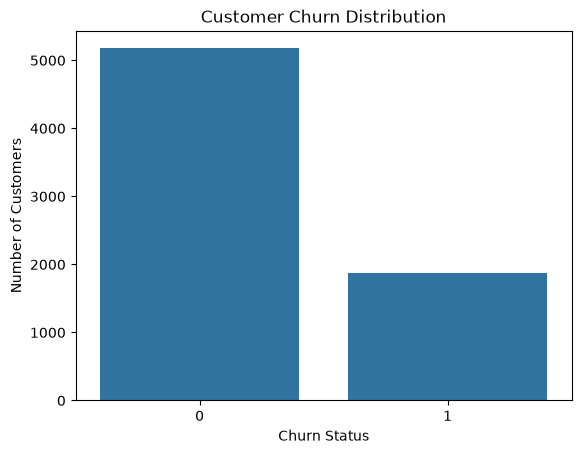

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    data=model_data,
    x="Churn Value"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

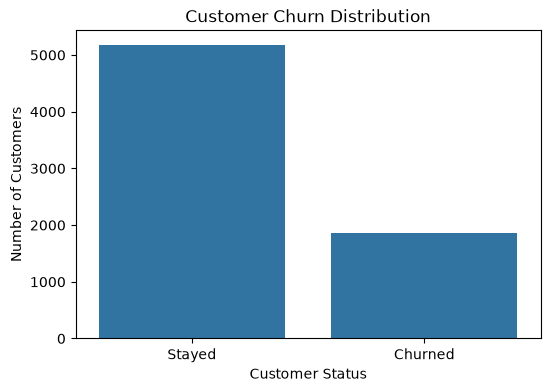

In [59]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=model_data,
    x="Churn Value"
)

plt.title("Customer Churn Distribution")

plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.xticks(
    ticks=[0,1],
    labels=["Stayed", "Churned"]
)

plt.show()

In [60]:
 model_data["Contract"].value_counts()

Contract
Month-to-Month    3610
Two Year          1883
One Year          1550
Name: count, dtype: int64

In [61]:
pd.crosstab(
    model_data["Contract"],
    model_data["Churn Value"]
)

Churn Value,0,1
Contract,,
Month-to-Month,1955,1655
One Year,1384,166
Two Year,1835,48


In [62]:
contract_churn = pd.crosstab(
    model_data["Contract"],
    model_data["Churn Value"],
    normalize="index"
) * 100

contract_churn

Churn Value,0,1
Contract,,
Month-to-Month,54.155125,45.844875
One Year,89.290323,10.709677
Two Year,97.450876,2.549124


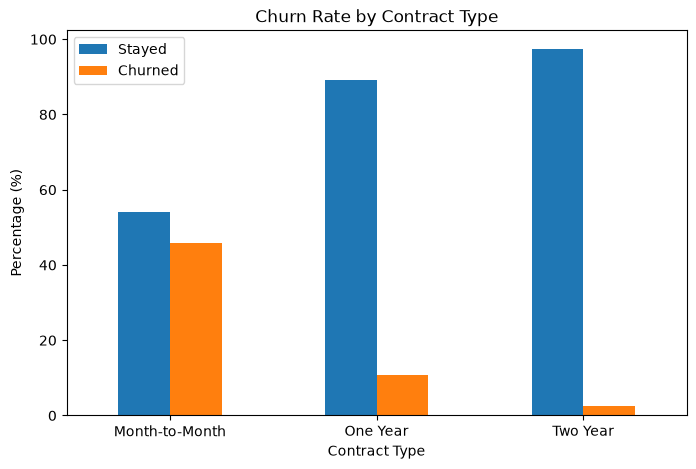

In [63]:
contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(
    ["Stayed", "Churned"]
)

plt.show()

In [64]:
model_data["Tenure in Months"].describe()

count    7043.000000
mean       32.386767
std        24.542061
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure in Months, dtype: float64

In [65]:
model_data.groupby("Churn Value")["Tenure in Months"].mean()

Churn Value
0    37.591225
1    17.979133
Name: Tenure in Months, dtype: float64

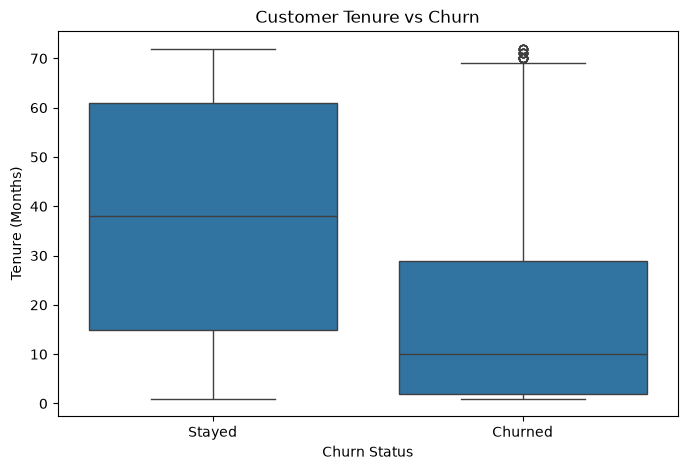

In [66]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=model_data,
    x="Churn Value",
    y="Tenure in Months"
)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.xticks(
    ticks=[0,1],
    labels=["Stayed","Churned"]
)

plt.show()

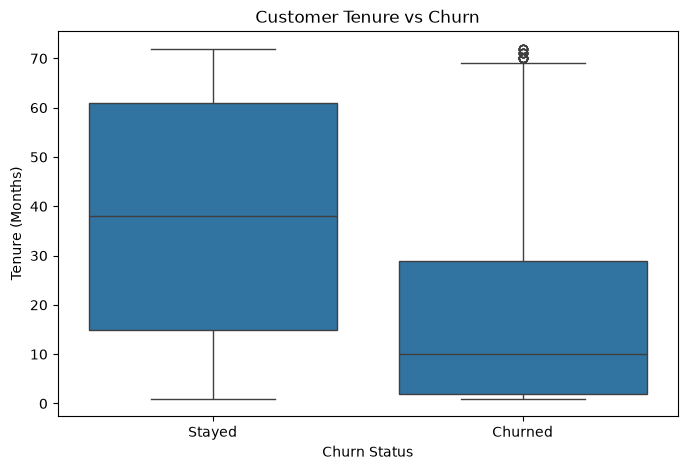

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=model_data,
    x="Churn Value",
    y="Tenure in Months"
)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.xticks(
    ticks=[0,1],
    labels=["Stayed","Churned"]
)

plt.show()

In [68]:
model_data.groupby("Churn Value")["Monthly Charge"].mean()

Churn Value
0    61.265124
1    74.441332
Name: Monthly Charge, dtype: float64

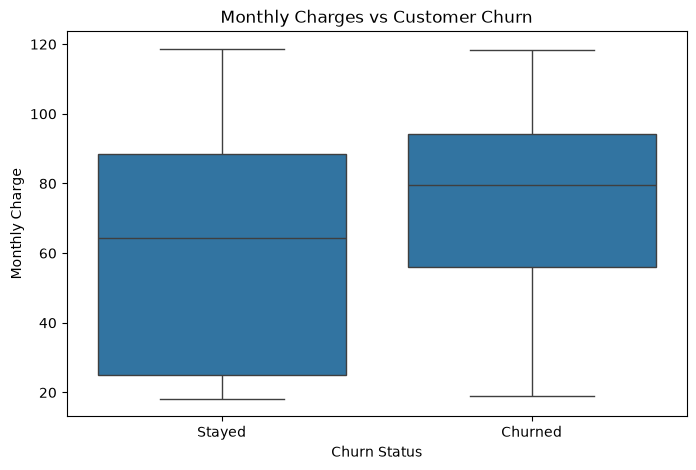

In [69]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=model_data,
    x="Churn Value",
    y="Monthly Charge"
)

plt.title("Monthly Charges vs Customer Churn")

plt.xlabel("Churn Status")
plt.ylabel("Monthly Charge")

plt.xticks(
    ticks=[0,1],
    labels=["Stayed","Churned"]
)

plt.show()

In [70]:
pd.crosstab(
    model_data["Payment Method"],
    model_data["Churn Value"]
)

Churn Value,0,1
Payment Method,,
Bank Withdrawal,2580,1329
Credit Card,2351,398
Mailed Check,243,142


In [71]:
payment_churn = pd.crosstab(
    model_data["Payment Method"],
    model_data["Churn Value"],
    normalize="index"
) * 100

payment_churn

Churn Value,0,1
Payment Method,,
Bank Withdrawal,66.001535,33.998465
Credit Card,85.522008,14.477992
Mailed Check,63.116883,36.883117


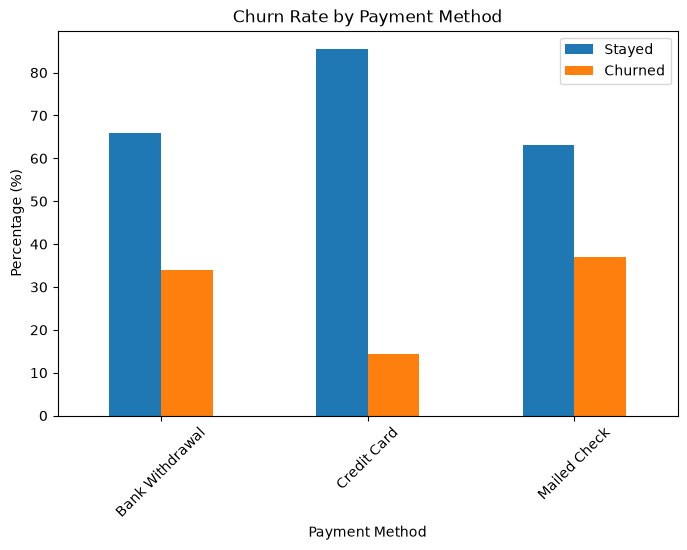

In [72]:
payment_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Payment Method")

plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=45)

plt.legend(
    ["Stayed","Churned"]
)

plt.show()

In [73]:
model_data["Internet Type"].value_counts()

Internet Type
Fiber Optic    3035
DSL            1652
No Internet    1526
Cable           830
Name: count, dtype: int64

In [74]:
internet_churn = pd.crosstab(
    model_data["Internet Type"],
    model_data["Churn Value"],
    normalize="index"
) * 100

internet_churn

Churn Value,0,1
Internet Type,,
Cable,74.337349,25.662651
DSL,81.416465,18.583535
Fiber Optic,59.275124,40.724876
No Internet,92.595020,7.404980


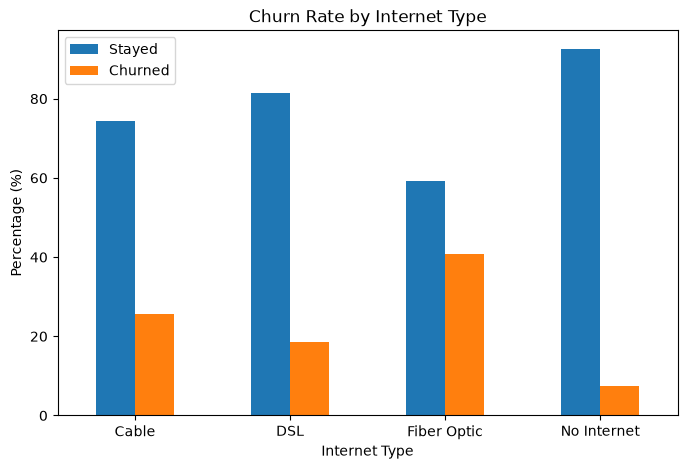

In [75]:
internet_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Internet Type")

plt.xlabel("Internet Type")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(
    ["Stayed","Churned"]
)

plt.show()

In [76]:
model_data["Satisfaction Score"].value_counts().sort_index()

Satisfaction Score
1     922
2     518
3    2665
4    1789
5    1149
Name: count, dtype: int64

In [77]:
model_data.groupby("Churn Value")["Satisfaction Score"].mean()

Churn Value
0    3.789911
1    1.736223
Name: Satisfaction Score, dtype: float64

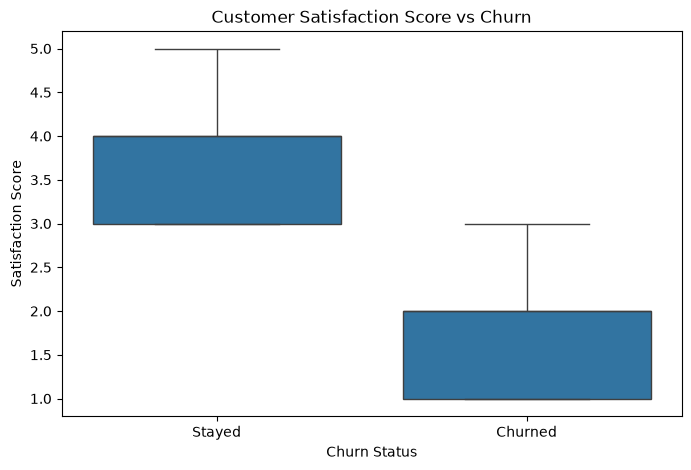

In [78]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=model_data,
    x="Churn Value",
    y="Satisfaction Score"
)

plt.title("Customer Satisfaction Score vs Churn")

plt.xlabel("Churn Status")
plt.ylabel("Satisfaction Score")

plt.xticks(
    ticks=[0,1],
    labels=["Stayed","Churned"]
)

plt.show()

In [79]:
model_data.groupby("Churn Value")["Age"].mean()

Churn Value
0    45.344414
1    49.735688
Name: Age, dtype: float64

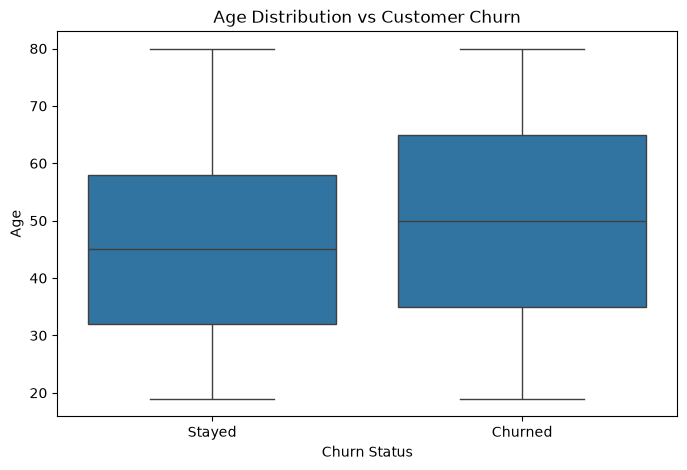

In [80]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=model_data,
    x="Churn Value",
    y="Age"
)

plt.title("Age Distribution vs Customer Churn")

plt.xlabel("Churn Status")
plt.ylabel("Age")

plt.xticks(
    ticks=[0,1],
    labels=["Stayed","Churned"]
)

plt.show()

In [81]:
senior_churn = pd.crosstab(
    model_data["Senior Citizen"],
    model_data["Churn Value"],
    normalize="index"
) * 100

senior_churn

Churn Value,0,1
Senior Citizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


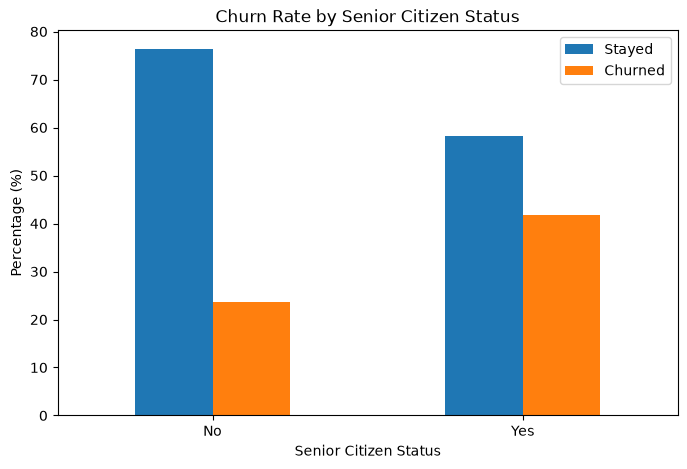

In [82]:
senior_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Senior Citizen Status")

plt.xlabel("Senior Citizen Status")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(
    ["Stayed","Churned"]
)

plt.show()

In [83]:
tech_support_churn = pd.crosstab(
    model_data["Premium Tech Support"],
    model_data["Churn Value"],
    normalize="index"
) * 100

tech_support_churn

Churn Value,0,1
Premium Tech Support,,
No,68.813763,31.186237
Yes,84.833659,15.166341


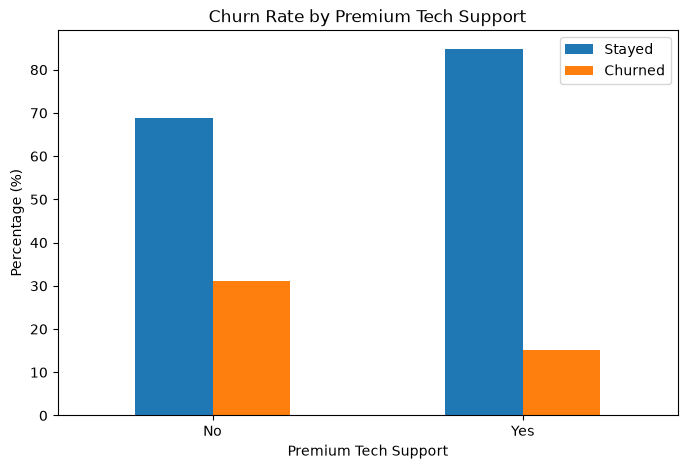

In [84]:
tech_support_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Premium Tech Support")

plt.xlabel("Premium Tech Support")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(
    ["Stayed","Churned"]
)

plt.show()

In [85]:
online_security_churn = pd.crosstab(
    model_data["Online Security"],
    model_data["Churn Value"],
    normalize="index"
) * 100

online_security_churn

Churn Value,0,1
Online Security,,
No,68.670382,31.329618
Yes,85.388806,14.611194


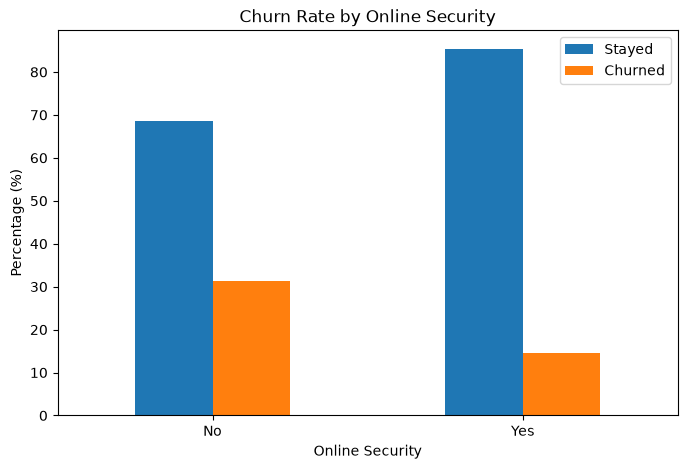

In [86]:
online_security_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Online Security")

plt.xlabel("Online Security")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(
    ["Stayed","Churned"]
)

plt.show()

In [87]:
online_backup_churn = pd.crosstab(
    model_data["Online Backup"],
    model_data["Churn Value"],
    normalize="index"
) * 100

online_backup_churn

Churn Value,0,1
Online Backup,,
No,70.827915,29.172085
Yes,78.468506,21.531494


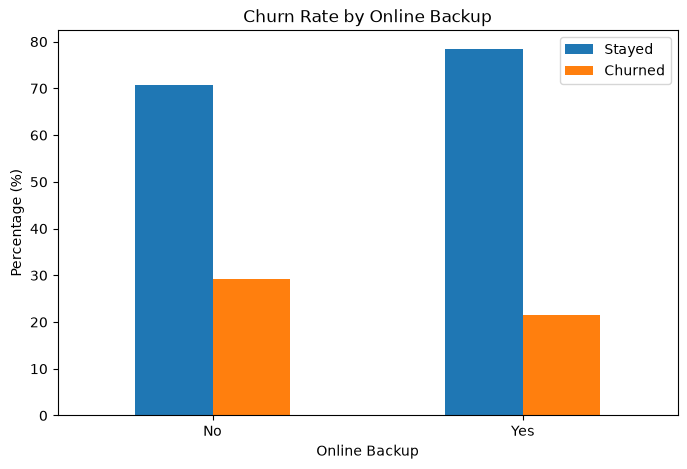

In [88]:
online_backup_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Online Backup")

plt.xlabel("Online Backup")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(
    ["Stayed","Churned"]
)

plt.show()

In [89]:
device_protection_churn = pd.crosstab(
    model_data["Device Protection Plan"],
    model_data["Churn Value"],
    normalize="index"
) * 100

device_protection_churn

Churn Value,0,1
Device Protection Plan,,
No,71.348193,28.651807
Yes,77.497936,22.502064


In [90]:
streaming_tv_churn = pd.crosstab(
    model_data["Streaming TV"],
    model_data["Churn Value"],
    normalize="index"
) * 100

streaming_tv_churn

Churn Value,0,1
Streaming TV,,
No,75.668819,24.331181
Yes,69.929812,30.070188


In [91]:
streaming_movies_churn = pd.crosstab(
    model_data["Streaming Movies"],
    model_data["Churn Value"],
    normalize="index"
) * 100

streaming_movies_churn

Churn Value,0,1
Streaming Movies,,
No,75.620506,24.379494
Yes,70.058565,29.941435


In [92]:
streaming_music_churn = pd.crosstab(
    model_data["Streaming Music"],
    model_data["Churn Value"],
    normalize="index"
) * 100

streaming_music_churn

Churn Value,0,1
Streaming Music,,
No,74.950604,25.049396
Yes,70.739550,29.260450


In [93]:
numeric_data = model_data.select_dtypes(include=["int64", "float64"])

In [94]:
numeric_data.corr()["Churn Value"].sort_values()

Satisfaction Score                  -0.754649
Tenure in Months                    -0.352861
Number of Referrals                 -0.286540
Total Long Distance Charges         -0.223756
Total Revenue                       -0.223003
Number of Dependents                -0.218780
Total Charges                       -0.198546
CLTV                                -0.127463
Latitude                            -0.041546
Total Refunds                       -0.033709
Zip Code                            -0.016289
Total Extra Data Charges             0.007139
Avg Monthly Long Distance Charges    0.008120
Longitude                            0.024052
Avg Monthly GB Download              0.048868
Age                                  0.115760
Monthly Charge                       0.193356
Churn Value                          1.000000
Name: Churn Value, dtype: float64

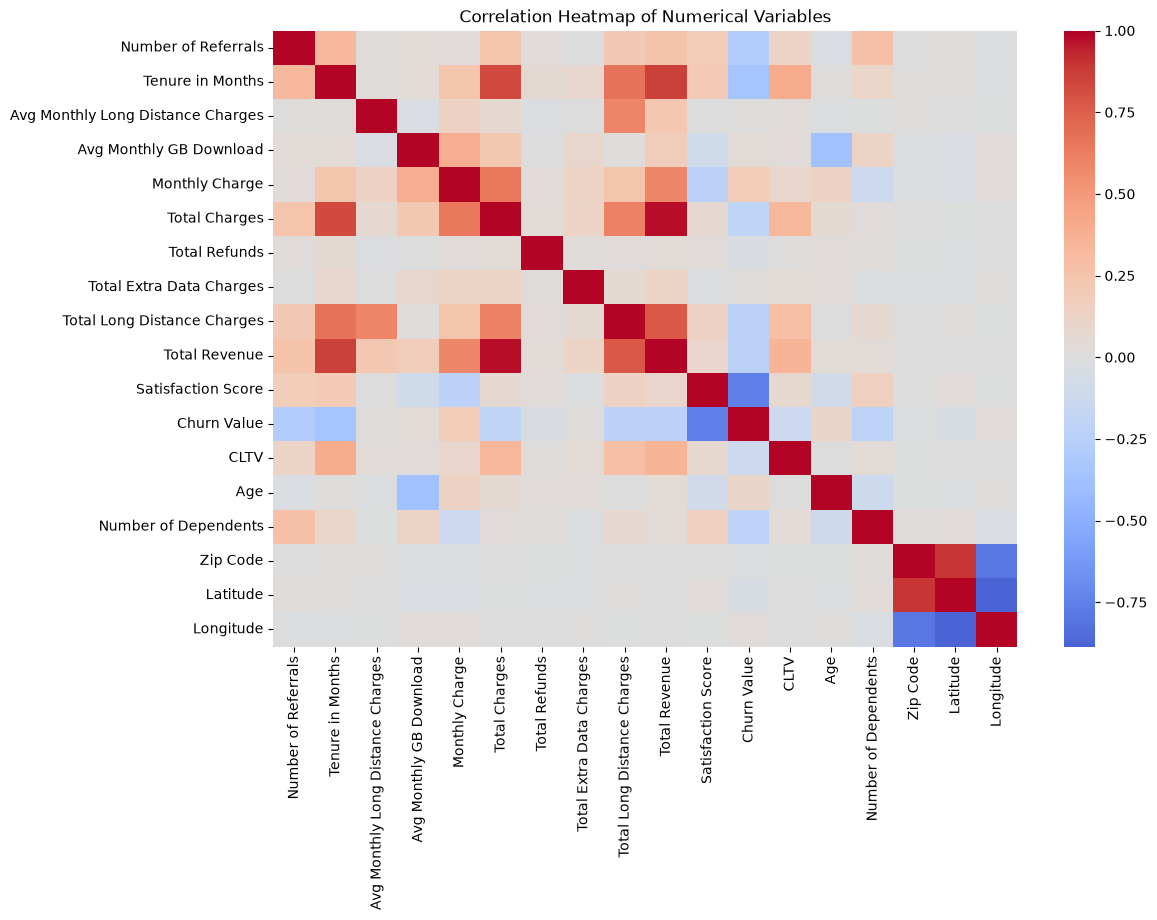

In [95]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_data.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

In [96]:
clean_data.to_csv("../data/customer_churn_cleaned.csv", index=False)

In [97]:
clean_data.shape

(7043, 54)

In [98]:
X = model_data.drop("Churn Value", axis=1)

y = model_data["Churn Value"]

In [99]:
X.shape

(7043, 42)

In [100]:
y.shape

(7043,)

In [101]:
X.select_dtypes(include="object").columns

C:\Users\FRIENDSL\AppData\Local\Temp\ipykernel_16160\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method', 'Gender', 'Under 30',
       'Senior Citizen', 'Married', 'Dependents', 'State', 'City',
       'Population'],
      dtype='str')

In [102]:
X.select_dtypes(include=["int64","float64"]).columns

Index(['Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
       'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'CLTV', 'Age',
       'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude'],
      dtype='str')

In [103]:
X["Population"] = X["Population"].str.replace(",", "").astype(int)

In [104]:
X["Population"].dtype

dtype('int64')

In [105]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

In [106]:
X_encoded.shape

(7043, 1153)

In [107]:
X_encoded.head()

,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,...,City_Wrightwood,City_Yermo,City_Yorba Linda,City_Yorkville,City_Yountville,City_Yreka,City_Yuba City,City_Yucaipa,City_Yucca Valley,City_Zenia
0,0,1,0.00,8,39.65,39.65,0.00,20,0.00,59.65,...,False,False,False,False,False,False,False,False,False,False
1,1,8,48.85,17,80.65,633.30,0.00,0,390.80,1024.10,...,False,False,False,False,False,False,False,False,False,False
2,0,18,11.33,52,95.45,1752.55,45.61,0,203.94,1910.88,...,False,False,False,False,False,False,False,False,False,False
3,1,25,19.76,12,98.50,2514.50,13.43,0,494.00,2995.07,...,False,False,False,False,False,False,False,False,False,False
4,1,37,6.33,14,76.50,2868.15,0.00,0,234.21,3102.36,...,False,False,False,False,False,False,False,False,False,False


In [108]:
X_encoded = X_encoded.astype(int)

In [109]:
X_encoded.head()

,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,...,City_Wrightwood,City_Yermo,City_Yorba Linda,City_Yorkville,City_Yountville,City_Yreka,City_Yuba City,City_Yucaipa,City_Yucca Valley,City_Zenia
0,0,1,0,8,39,39,0,20,0,59,...,0,0,0,0,0,0,0,0,0,0
1,1,8,48,17,80,633,0,0,390,1024,...,0,0,0,0,0,0,0,0,0,0
2,0,18,11,52,95,1752,45,0,203,1910,...,0,0,0,0,0,0,0,0,0,0
3,1,25,19,12,98,2514,13,0,494,2995,...,0,0,0,0,0,0,0,0,0,0
4,1,37,6,14,76,2868,0,0,234,3102,...,0,0,0,0,0,0,0,0,0,0


In [110]:
X_encoded.shape

(7043, 1153)

In [111]:
len([col for col in X_encoded.columns if "City" in col])

1105

In [112]:
len([col for col in X_encoded.columns if "State" in col])

0

In [113]:
len([col for col in X_encoded.columns if "Zip" in col])

1

In [114]:
X_clean = X.drop(
    columns=[
        "City",
        "State",
        "Zip Code",
        "Latitude",
        "Longitude",
        "Population"
    ]
)

In [115]:
X_encoded = pd.get_dummies(
    X_clean,
    drop_first=True
)

X_encoded = X_encoded.astype(int)

In [116]:
X_encoded.shape

(7043, 44)

In [117]:
X_encoded = pd.get_dummies(
    X_clean,
    drop_first=True
)

X_encoded = X_encoded.astype(int)

In [118]:
X_encoded.shape

(7043, 44)

In [119]:
X_clean.dtypes.value_counts()

str        22
int64       8
float64     6
Name: count, dtype: int64

In [120]:
X_encoded.dtypes.value_counts()

int64    44
Name: count, dtype: int64

In [121]:
from sklearn.model_selection import train_test_split

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [123]:
X_train.shape

(5634, 44)

In [124]:
X_test.shape

(1409, 44)

In [125]:
y_train.shape

(5634,)

In [126]:
y_test.shape

(1409,)

In [127]:
from sklearn.linear_model import LogisticRegression

In [128]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [129]:
log_model.fit(
    X_train,
    y_train
)

C:\Users\FRIENDSL\anaconda3\envs\customer_churn\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [130]:
from sklearn.preprocessing import StandardScaler

In [131]:
scaler = StandardScaler()

In [132]:
X_train_scaled = scaler.fit_transform(X_train)

In [133]:
X_test_scaled = scaler.transform(X_test)

In [134]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [135]:
log_model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [136]:
y_pred = log_model.predict(
    X_test_scaled
)

In [137]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [138]:
accuracy_score(
    y_test,
    y_pred
)

0.9609652235628106

In [139]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1035
           1       0.95      0.90      0.92       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



In [140]:
confusion_matrix(
    y_test,
    y_pred
)

array([[1018,   17],
       [  38,  336]])

In [141]:
log_model.coef_

array([[-1.93580031e+00, -8.61799431e-01, -1.14600773e-01,
         1.32468649e-02,  9.50195485e-01, -6.90185533e-02,
        -5.54807625e-02,  2.74665248e-02,  2.95133911e-01,
         3.29714062e-02, -6.96789518e+00,  1.46148070e-02,
         6.50958391e-02,  3.29847408e-01,  6.60163166e-01,
         4.86894841e-01,  1.16040414e-01, -6.72168026e-02,
        -1.54095945e-01,  1.52931793e-01, -3.73194722e-01,
         1.22530168e-01, -5.34541221e-02, -1.08912393e-01,
        -1.76837445e-01,  5.34541221e-02, -1.27270186e+00,
        -2.35262551e-01,  9.60608505e-02, -2.85228933e-01,
        -6.14412243e-02, -3.04543454e-01,  3.83297675e-01,
         1.60098978e-03, -3.50937179e-01, -8.69928446e-01,
         2.03717333e-01, -2.50332358e-01, -8.16907126e-03,
        -6.57473214e-02, -1.15313117e-02,  2.33648116e-01,
         2.24652441e-01, -9.98867683e-01]])

In [142]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": log_model.coef_[0]
})

feature_importance

,Feature,Coefficient
0,Number of Referrals,-1.935800
1,Tenure in Months,-0.861799
2,Avg Monthly Long Distance Charges,-0.114601
3,Avg Monthly GB Download,0.013247
4,Monthly Charge,0.950195
5,Total Charges,-0.069019
6,Total Refunds,-0.055481
7,Total Extra Data Charges,0.027467
8,Total Long Distance Charges,0.295134
9,Total Revenue,0.032971


In [143]:
feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
4,Monthly Charge,0.950195
14,Referred a Friend_Yes,0.660163
15,Offer_Offer A,0.486895
32,Streaming Music_Yes,0.383298
13,Number of Dependents,0.329847
8,Total Long Distance Charges,0.295134
41,Senior Citizen_Yes,0.233648
42,Married_Yes,0.224652
36,Paperless Billing_Yes,0.203717
19,Offer_Offer E,0.152932


In [144]:
feature_importance.sort_values(
    by="Coefficient",
    ascending=True
)

,Feature,Coefficient
10,Satisfaction Score,-6.967895
0,Number of Referrals,-1.935800
26,Online Security_Yes,-1.272702
43,Dependents_Yes,-0.998868
35,Contract_Two Year,-0.869928
1,Tenure in Months,-0.861799
20,Phone Service_Yes,-0.373195
34,Contract_One Year,-0.350937
31,Streaming Movies_Yes,-0.304543
29,Premium Tech Support_Yes,-0.285229


In [145]:
log_model.predict_proba()

TypeError: LogisticRegression.predict_proba() missing 1 required positional argument: 'X'

In [146]:
y_probability = log_model.predict_proba(
    X_test_scaled
)

In [147]:
y_probability[:5]

array([[9.99442055e-01, 5.57945440e-04],
       [9.99986600e-01, 1.33995678e-05],
       [9.99999094e-01, 9.06279726e-07],
       [9.99860041e-01, 1.39959382e-04],
       [9.99993361e-01, 6.63853810e-06]])

In [148]:
churn_probability = y_probability[:,1]

In [149]:
churn_probability[:10]

array([5.57945440e-04, 1.33995678e-05, 9.06279726e-07, 1.39959382e-04,
       6.63853810e-06, 5.68407801e-03, 1.62186535e-05, 7.59533207e-01,
       1.30727094e-03, 9.99999220e-01])

In [150]:
churn_probability = y_probability[:,1]

In [151]:
prediction_results = pd.DataFrame({
    "Actual Churn": y_test.values,
    "Churn Probability": churn_probability,
    "Predicted Churn": y_pred
})

prediction_results.head()

,Actual Churn,Churn Probability,Predicted Churn
0,0,5.579454e-04,0
1,0,1.339957e-05,0
2,0,9.062797e-07,0
3,0,1.399594e-04,0
4,0,6.638538e-06,0


In [152]:
prediction_results["Risk Level"] = pd.cut(
    prediction_results["Churn Probability"],
    bins=[0,0.3,0.7,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

In [153]:
prediction_results.head()

,Actual Churn,Churn Probability,Predicted Churn,Risk Level
0,0,5.579454e-04,0,Low Risk
1,0,1.339957e-05,0,Low Risk
2,0,9.062797e-07,0,Low Risk
3,0,1.399594e-04,0,Low Risk
4,0,6.638538e-06,0,Low Risk


In [154]:
prediction_results["Churn Probability (%)"] = (
    prediction_results["Churn Probability"] * 100
).round(2)

In [155]:
prediction_results.head()

,Actual Churn,Churn Probability,Predicted Churn,Risk Level,Churn Probability (%)
0,0,5.579454e-04,0,Low Risk,0.06
1,0,1.339957e-05,0,Low Risk,0.00
2,0,9.062797e-07,0,Low Risk,0.00
3,0,1.399594e-04,0,Low Risk,0.01
4,0,6.638538e-06,0,Low Risk,0.00


In [156]:
prediction_results["Risk Level"].value_counts()

Risk Level
Low Risk       1014
High Risk       318
Medium Risk      77
Name: count, dtype: int64

In [157]:
prediction_results.to_csv(
    "../data/churn_predictions.csv",
    index=False
)

In [158]:
import joblib

In [159]:
joblib.dump(
    log_model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

In [160]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [161]:
joblib.dump(
    X_encoded.columns,
    "../models/features.pkl"
)

['../models/features.pkl']

In [162]:
joblib.dump(
    log_model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

In [163]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [164]:
joblib.dump(
    X_encoded.columns,
    "../models/features.pkl"
)

['../models/features.pkl']

In [165]:
import os

os.listdir("../models")

['churn_model.pkl', 'features.pkl', 'scaler.pkl']